In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow Version:", tf.__version__)

2025-11-27 22:16:27.816801: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764281788.033017      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764281788.108798      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0


In [2]:
path = '/kaggle/input/pathogen-dataset/pathogen'

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 15

In [4]:
#  a list of all image filepaths and their corresponding labels.
filepaths = []
labels = []

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        filepaths.append(os.path.join(dirname, filename))
        labels.append(os.path.basename(dirname))

df = pd.DataFrame({'filepath': filepaths, 'label': labels})
print("DataFrame created successfully. First 5 rows:")
print(df.head())

DataFrame created successfully. First 5 rows:
                                            filepath     label
0  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria
1  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria
2  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria
3  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria
4  /kaggle/input/pathogen-dataset/pathogen/Bacter...  Bacteria


In [5]:
# --- Splitting the Data ---
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"\nTraining samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

num_classes = len(df['label'].unique())
print(f"Number of classes found: {num_classes}")


Training samples: 31997
Validation samples: 4000
Test samples: 4000
Number of classes found: 5


In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,      
    width_shift_range=0.2,   
    height_shift_range=0.2,  
    shear_range=0.2,        
    zoom_range=0.2,          
    horizontal_flip=True,
    fill_mode='nearest'
)

# The validation and test generators should not have augmentations, only preprocessing.

val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

# --- Create the generators from our DataFrames ---
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 31997 validated image filenames belonging to 5 classes.
Found 4000 validated image filenames belonging to 5 classes.
Found 4000 validated image filenames belonging to 5 classes.


In [7]:
# Load the base ٌٌٌResNet50 model, pre-trained on ImageNet
base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze the base model to use it as a feature extractor
base_model.trainable = False

# Create our custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
num_classes = num_classes
outputs = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=outputs)

# Compile the model
model.compile(
    
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

I0000 00:00:1764281853.691734      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764281853.692398      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,691,013 (98.00 MB)

 Trainable params: 2,103,301 (8.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
# This callback will save the best version of our model based on validation accuracy.
# This ensures we keep the model that performed best, even if it overfits later.

model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# This callback will stop the training process if the model's performance on the
# validation set stops improving for 5 consecutive epochs. This saves time and resources.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True, # Automatically loads the best weights at the end
    verbose=1
)
# --- Start Initial Training ---
print("\n--- Starting Initial Training (Frozen Base Model) ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[model_checkpoint, early_stopping],
    verbose=1,
    shuffle=True
)


--- Starting Initial Training (Frozen Base Model) ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1764281868.773888      63 service.cc:148] XLA service 0x7b1d980023a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764281868.774852      63 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764281868.774877      63 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764281870.431847      63 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/2000 ━━━━━━━━━━━━━━━━━━━━ 9:27:50 17s/step - accuracy: 0.1250 - loss: 2.0808

I0000 00:00:1764281874.777551      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.8703 - loss: 0.4248
Epoch 1: val_accuracy improved from -inf to 0.94525, saving model to best_model.keras
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 570s 277ms/step - accuracy: 0.8704 - loss: 0.4247 - val_accuracy: 0.9452 - val_loss: 0.1725
Epoch 2/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9509 - loss: 0.1456
Epoch 2: val_accuracy improved from 0.94525 to 0.96650, saving model to best_model.keras
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 459s 230ms/step - accuracy: 0.9509 - loss: 0.1456 - val_accuracy: 0.9665 - val_loss: 0.1069
Epoch 3/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9572 - loss: 0.1288
Epoch 3: val_accuracy did not improve from 0.96650
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 456s 228ms/step - accuracy: 0.9572 - loss: 0.1288 - val_accuracy: 0.9572 - val_loss: 0.1548
Epoch 4/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9597 - loss: 0.1227
Epoch 4: val_accuracy did not improve from 0.96650
2000/

In [9]:
print("\n--- Starting Fine-Tuning Phase ---")

# Unfreeze the base model
base_model.trainable = True

# We will only fine-tune the top layers.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile with a very low learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE / 100),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Continue training
history_fine = model.fit(
    train_generator,
    epochs=EPOCHS, # Let EarlyStopping decide the true number
    validation_data=validation_generator,
    initial_epoch=history.epoch[-1],
    callbacks=[model_checkpoint, early_stopping]
)


--- Starting Fine-Tuning Phase ---
Epoch 11/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9386 - loss: 0.2008
Epoch 11: val_accuracy improved from 0.97950 to 0.98000, saving model to best_model.keras
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 512s 237ms/step - accuracy: 0.9386 - loss: 0.2008 - val_accuracy: 0.9800 - val_loss: 0.0749
Epoch 12/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9795 - loss: 0.0672
Epoch 12: val_accuracy improved from 0.98000 to 0.98450, saving model to best_model.keras
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 460s 230ms/step - accuracy: 0.9795 - loss: 0.0672 - val_accuracy: 0.9845 - val_loss: 0.0611
Epoch 13/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9840 - loss: 0.0488
Epoch 13: val_accuracy did not improve from 0.98450
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 464s 232ms/step - accuracy: 0.9840 - loss: 0.0488 - val_accuracy: 0.9845 - val_loss: 0.0646
Epoch 14/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9874 - loss: 0.0399


--- Preparing Final Analysis ---

--- Plotting Combined Learning Curves ---


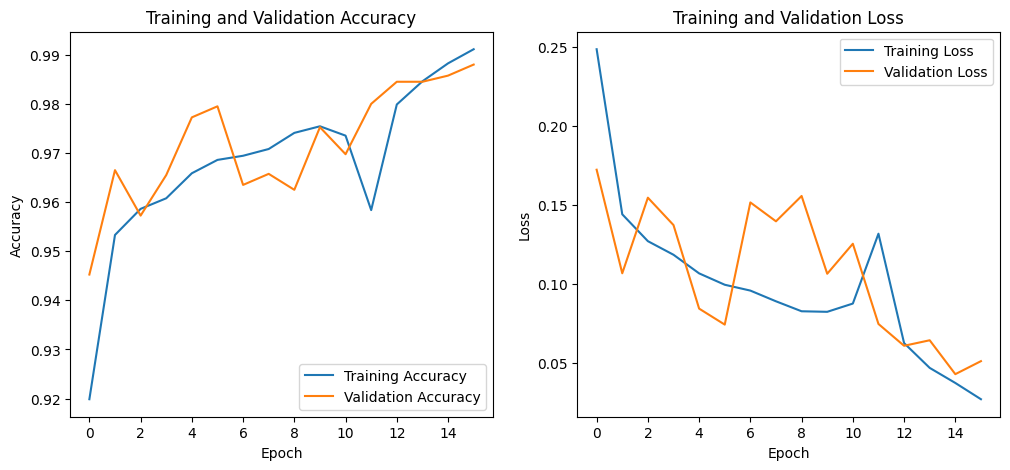


--- Loading the best performing model from 'best_model.keras' ---

--- Evaluating the BEST Performing Model on the Test Set ---
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 134ms/step - accuracy: 0.9871 - loss: 0.0458
Final Test Accuracy: 98.60%


In [10]:
import matplotlib.pyplot as plt
import tensorflow as tf

print("\n--- Preparing Final Analysis ---")

# We will combine the results from the initial training and the fine-tuning phase
# to create a complete graph of the entire learning process.
# This assumes 'history' and 'history_fine' objects exist from the previous cells.
if 'history' in locals() and 'history_fine' in locals():
    acc = history.history['accuracy'] + history_fine.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
    loss = history.history['loss'] + history_fine.history['loss']
    val_loss = history.history['val_loss'] + history_fine.history['val_loss']
else:
    # Fallback to just the fine-tuning history if the initial one is not available
    acc = history_fine.history['accuracy']
    val_acc = history_fine.history['val_accuracy']
    loss = history_fine.history['loss']
    val_loss = history_fine.history['val_loss']
    
# --- This is your new, robust plotting code ---
# It safely checks if the validation metrics are available before plotting.
if val_acc and val_loss:
    print("\n--- Plotting Combined Learning Curves ---")
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

# --- Load the BEST performing model that was saved by the ModelCheckpoint callback ---
print("\n--- Loading the best performing model from 'best_model.keras' ---")
best_model = tf.keras.models.load_model('best_model.keras')

# --- Evaluate the best model on the completely unseen test data ---
# This is the most honest measure of our model's real-world performance.
print("\n--- Evaluating the BEST Performing Model on the Test Set ---")
loss, accuracy = best_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

In [11]:
# --- Export the BEST model to TFLite ---
print("\n--- Exporting the Best Model to TFLite ---")
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Apply standard optimizations
tflite_model = converter.convert()

# Save the final files with new names
with open('pathogen_model_final.tflite', 'wb') as f:
    f.write(tflite_model)

class_names = list(train_generator.class_indices.keys())
with open('pathogen_labels_final.txt', 'w') as f:
    f.write('\n'.join(class_names))

print("\nSuccessfully exported 'pathogen_model_final.tflite' and 'pathogen_labels_final.txt'")


--- Exporting the Best Model to TFLite ---
Saved artifact at '/tmp/tmpbqtbc6j7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135366952058512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135366952058704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135366096372944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135366096371984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135366096372752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135366096371792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135366096374480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135366096375056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135366096375248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135366096374096: TensorSpec(shape=(), dty

W0000 00:00:1764289408.024243      20 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1764289408.024289      20 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1764289408.188442      20 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled



Successfully exported 'pathogen_model_final.tflite' and 'pathogen_labels_final.txt'


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


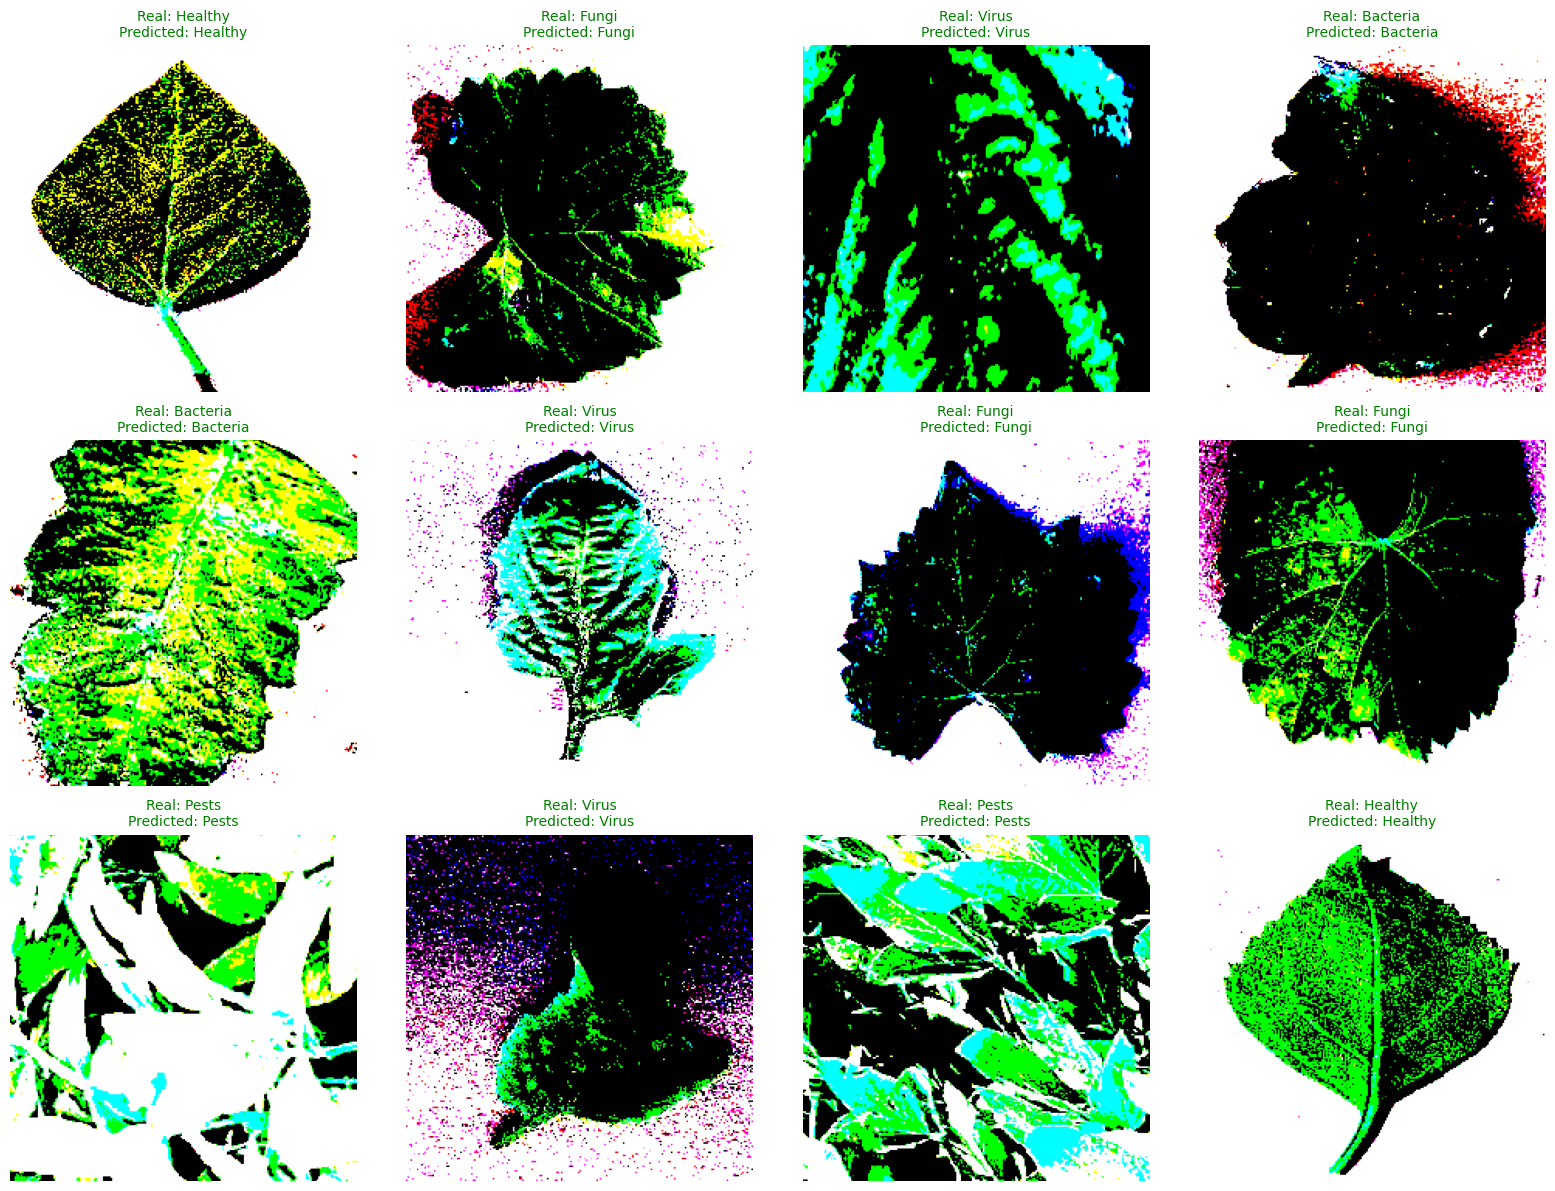

In [12]:
# Get the next batch of images from the test generator
batch = next(test_generator)
images, labels = batch

# Get predictions from the model for the batch of images
# Using 'best_model' which was loaded in Cell 9 is recommended
predictions = best_model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)

# The class_names variable is a list of strings
class_names_list = list(class_names)

# Rescale images from [-1, 1] to [0, 1] for correct display
def deprocess_image(img):
    return (img + 1) / 2.0

# Display the first 12 images with their actual and predicted labels
plt.figure(figsize=(16, 12))
for i in range(12):
    if i >= len(images): # Ensure we don't go out of bounds if batch is smaller than 12
        break
    plt.subplot(3, 4, i + 1)
    # Apply the deprocessing function before showing the image
    plt.imshow(deprocess_image(images[i]))
    
    real_label = class_names_list[np.argmax(labels[i])]
    predicted_label = class_names_list[predicted_labels[i]]
    
    # Set title color to green for correct predictions, red for incorrect
    title_color = 'green' if real_label == predicted_label else 'red'
    
    plt.title(f'Real: {real_label}\nPredicted: {predicted_label}', fontsize=10, color=title_color)
    plt.axis('off')

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

Preparing to test the model
Loaded 5 class labels.
Model expects input shape: (224, 224)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


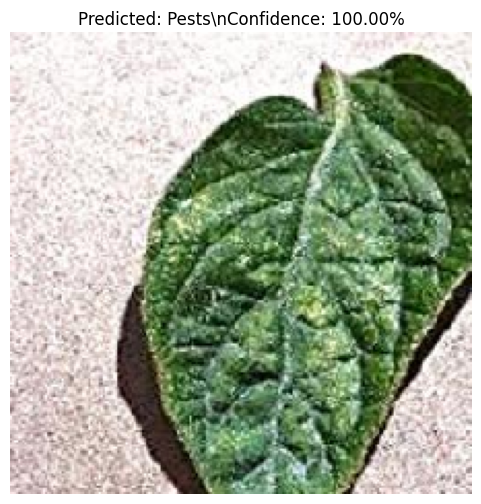


Prediction complete.


In [13]:
from tensorflow.keras.preprocessing import image

print("Preparing to test the model")

MODEL_PATH = '/kaggle/working/pathogen_model_final.tflite'
LABELS_PATH = '/kaggle/working/pathogen_labels_final.txt'
TEST_IMAGE_PATH = '/kaggle/input/pathogen-dataset/pathogen/Pests/Pests_original_enhanced_image_1003.jpg_4d9d77a6-b2f4-446f-b18e-73e5de3a2dcf.jpg'

# Load the Model and Labels
with open(LABELS_PATH, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]
print(f"Loaded {len(class_names)} class labels.")

interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
_, height, width, _ = input_details[0]['shape']

print(f"Model expects input shape: ({height}, {width})")

img = image.load_img(TEST_IMAGE_PATH, target_size=(height, width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

preprocessed_img = tf.keras.applications.resnet50.preprocess_input(img_array)

# Make a Prediction
interpreter.set_tensor(input_details[0]['index'], preprocessed_img)
interpreter.invoke()
predictions = interpreter.get_tensor(output_details[0]['index'])

# Interpret and Display the Result
predicted_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_index]
confidence_score = np.max(predictions[0])

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class_name}\\nConfidence: {confidence_score*100:.2f}%")
plt.axis("off")
plt.show()

print("\nPrediction complete.")